# Statistical Rethinking ch13 — Bangladesh contraceptive use (district varying intercept)

Frequentist port of McElreath's Bangladesh contraceptive-use example
(*Statistical Rethinking* 2nd ed., scripts/13_varying_features_bangladesh.R),
fit with **interlace.glmer** and validated against `lme4::glmer`. This is the
real-data baseline for T5 (varying slopes), and demonstrates clean parity on a
non-simulated dataset with substantial district-level shrinkage.

**Dataset.** 1934 Bangladeshi women across 60 administrative districts, from
the 1989 Bangladesh Fertility Survey. Outcome `use_contraception` is binary
(uses any modern method ↔ does not). Predictors:

| Column            | Meaning                                |
|-------------------|----------------------------------------|
| `urban`           | 1 if urban, 0 if rural                 |
| `age_centered`    | woman's age, centered at the mean      |
| `living_children` | number of living children              |
| `district`        | district id (1..61, level 54 missing)  |

**Models.**

$$ \mathrm{use\_contraception}_i \sim \mathrm{Bernoulli}(p_i) $$
$$ \mathrm{logit}\,p_i = X_i\beta + \alpha_{\mathrm{district}[i]},\quad \alpha_d \sim \mathcal{N}(0,\,\sigma_d^2). $$

| Model | Linear predictor                                                                |
|-------|---------------------------------------------------------------------------------|
| M0    | `1 + (1\|district)`                                                              |
| M1    | `urban + (1\|district)`                                                          |
| M2    | `urban + age_centered + living_children + (1\|district)`                         |

References: `tests/fixtures/sr_13_bangladesh_M{0..2}_results.json` (lme4-bobyqa).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import plotnine as p9
from plotnine import (
    ggplot, aes, geom_point, geom_segment, geom_hline, geom_vline,
    labs, theme_bw, theme,
)

import interlace

FIXTURE_DIR = Path("../../tests/fixtures")


## 1. Data preparation

In [2]:
df = pd.read_csv(FIXTURE_DIR / "sr_13_bangladesh_data.csv")
print(f"Observations : {len(df)}")
print(f"Districts    : {df['district'].nunique()} (gap: 54 absent)")
print(f"Urban share  : {df['urban'].mean():.2%}")
print(f"Use rate     : {df['use_contraception'].mean():.2%}")
df.head()


Observations : 1934
Districts    : 60 (gap: 54 absent)
Urban share  : 29.06%
Use rate     : 39.25%


,woman,district,use_contraception,living_children,age_centered,urban
0,1,1,0,4,18.4400,1
1,2,1,0,1,-5.5599,1
2,3,1,0,3,1.4400,1
3,4,1,0,4,8.4400,1
4,5,1,0,1,-13.5590,1


## 2. EDA — sample size and raw use rate by district

Districts vary widely in N (the smallest has just a handful of women), which
is exactly the regime where shrinkage helps the most.

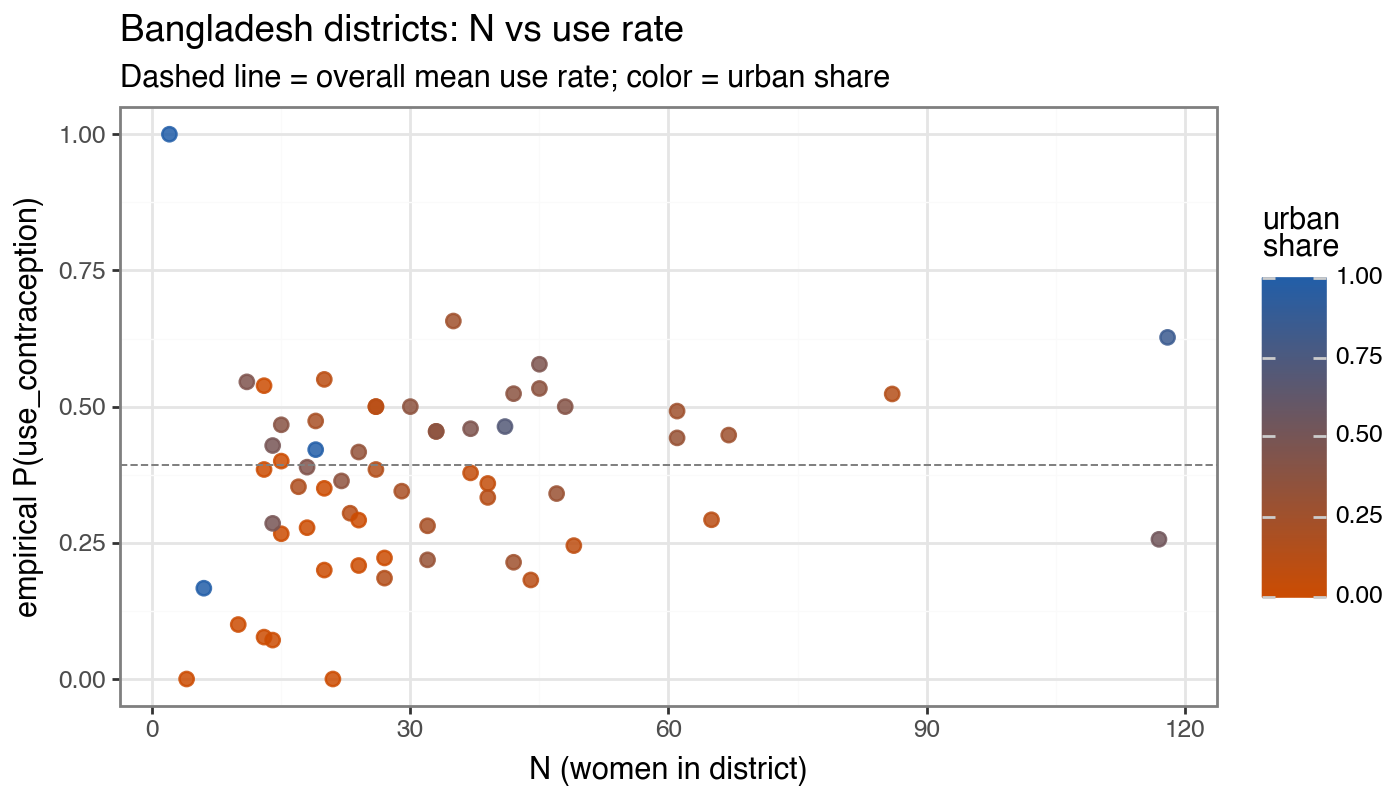

In [3]:
district_summary = (
    df.groupby("district")
      .agg(n=("woman", "size"),
           urban_share=("urban", "mean"),
           use_rate=("use_contraception", "mean"))
      .reset_index()
)

(
    ggplot(district_summary, aes("n", "use_rate", color="urban_share"))
    + geom_point(size=2.4, alpha=0.85)
    + geom_hline(yintercept=df["use_contraception"].mean(),
                 linetype="dashed", color="grey", size=0.4)
    + p9.scale_color_gradient(low="#cc4c02", high="#225ea8")
    + labs(
        title="Bangladesh districts: N vs use rate",
        subtitle="Dashed line = overall mean use rate; color = urban share",
        x="N (women in district)",
        y="empirical P(use_contraception)",
        color="urban\nshare",
    )
    + theme_bw()
    + theme(figure_size=(7, 4))
)


## 3. M0 — intercept-only varying intercept

The simplest fit: each district has its own logit intercept, drawn from a
common Gaussian. No predictors yet.

In [4]:
def fit_bgd(formula: str):
    return interlace.glmer(formula, data=df, family="binomial", groups="district")

M0 = fit_bgd("use_contraception ~ 1")
print(M0.summary())


Generalized linear mixed model fit by Laplace
Family: binomial
Formula: use_contraception ~ 1

Fixed effects:
                           Estimate   Std. Error    z value
  Intercept                 -0.5378       0.0840    -6.4064

Random effects:
  district        Var: 0.245700  SD: 0.495681  (n=60)

Number of obs: 1934, groups: district: 60
AIC: 2538.45  BIC: 2549.59  logLik: -1267.23
Optimizer: converged


In [5]:
def report_parity(fit, ref_path: Path, name_map: dict[str, str]):
    ref = json.loads(ref_path.read_text())
    print(f"=== {ref_path.name} validation ===")
    print(f"{'parameter':<22} {'interlace':>11} {'R lme4':>11} {'diff':>11}")
    print("-" * 60)
    for r_name, r_val in ref["fixed_effects"].items():
        py_val = float(fit.fe_params[name_map[r_name]])
        print(f"{r_name:<22} {py_val:>+11.4f} {r_val:>+11.4f} {py_val - r_val:>+11.2e}")
    r_var = ref["variance_components"]["district"]
    py_var = float(fit.variance_components["district"])
    print(f"{'sigma2_district':<22} {py_var:>11.4f} {r_var:>11.4f} {(py_var - r_var)/r_var:>+11.2%}")
    print(f"{'logLik':<22} {float(fit.llf):>+11.4f} {ref['loglik']:>+11.4f} {float(fit.llf) - ref['loglik']:>+11.2e}")
    # BLUP correlation
    r_re = ref["ranef_district"]
    levels = sorted(int(k) for k in r_re)
    r_arr = np.array([r_re[str(i)] for i in levels])
    py_arr = np.array([float(fit.random_effects["district"].loc[i]) for i in levels])
    print(f"{'BLUP corr':<22} {np.corrcoef(r_arr, py_arr)[0, 1]:>11.4f}")

report_parity(M0, FIXTURE_DIR / "sr_13_bangladesh_M0_results.json",
              {"(Intercept)": "Intercept"})


=== sr_13_bangladesh_M0_results.json validation ===
parameter                interlace      R lme4        diff
------------------------------------------------------------
(Intercept)                -0.5378     -0.5378   -1.69e-05
sigma2_district             0.2457      0.2457      +0.01%
logLik                  -1267.2265  -1267.2265   +1.06e-05
BLUP corr                   1.0000


### Shrinkage figure (district intercepts)

Compare each district's no-pooling empirical logit to its M0 partial-pooling
estimate. The horizontal axis is N: small-N districts get pulled hard toward
the grand mean, large-N districts barely move.

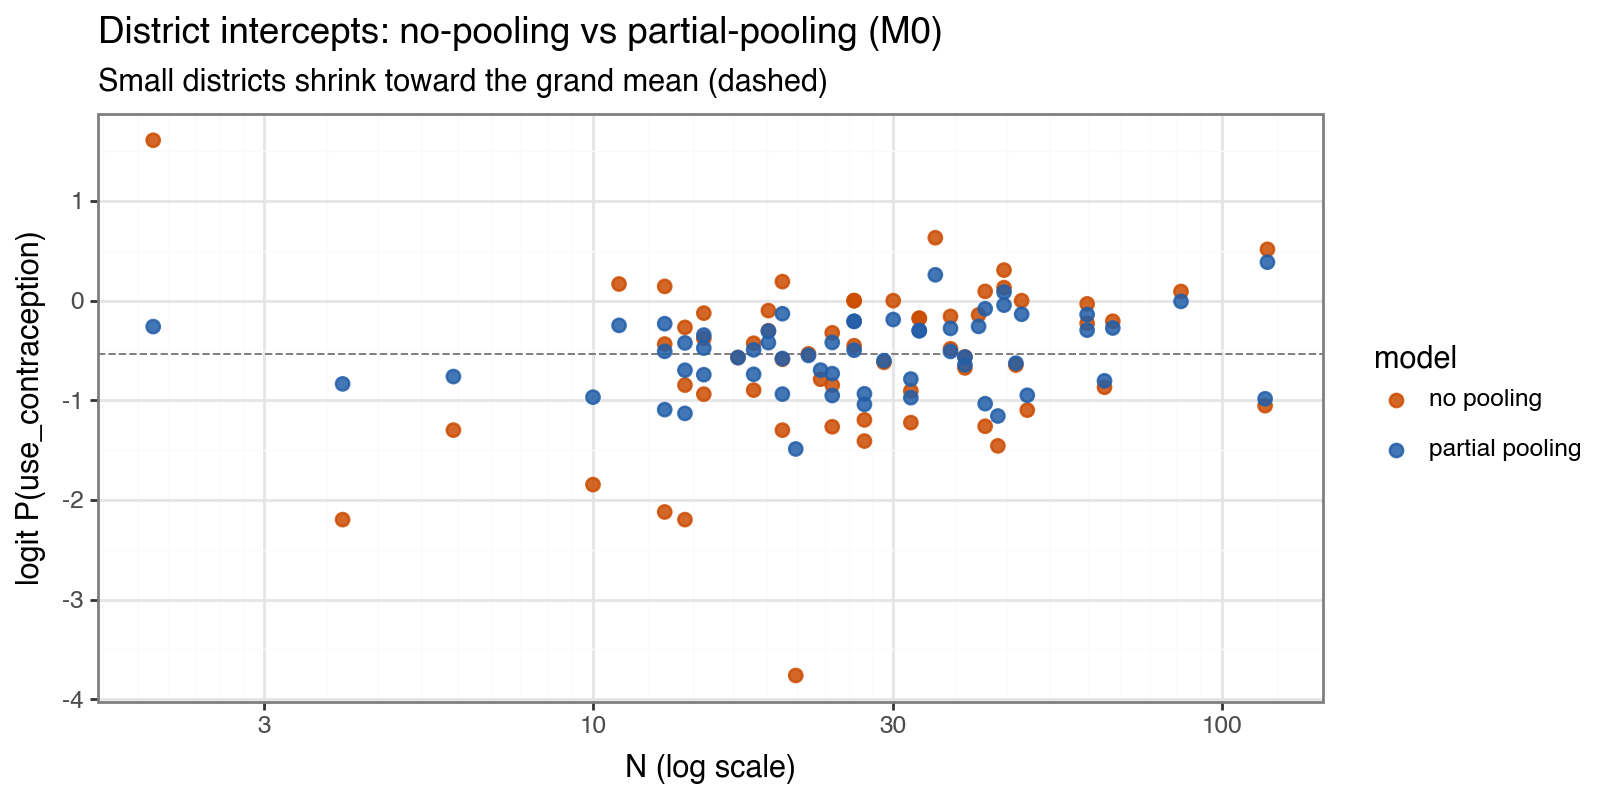

In [6]:
def empirical_logit(s, n):
    p = (s + 0.5) / (n + 1.0)
    return np.log(p / (1 - p))

district_summary["logit_np"] = empirical_logit(
    district_summary["use_rate"].to_numpy() * district_summary["n"].to_numpy(),
    district_summary["n"].to_numpy(),
)

alpha_bar_M0 = float(M0.fe_params["Intercept"])
blups_M0 = M0.random_effects["district"]
district_summary["logit_pp"] = (
    alpha_bar_M0 + blups_M0.loc[district_summary["district"]].to_numpy()
)

shrink_long = pd.concat([
    district_summary.assign(model="no pooling", logit=district_summary["logit_np"]),
    district_summary.assign(model="partial pooling", logit=district_summary["logit_pp"]),
])[["district", "n", "model", "logit"]]

(
    ggplot(shrink_long, aes("n", "logit", color="model"))
    + geom_hline(yintercept=alpha_bar_M0, linetype="dashed", color="grey", size=0.4)
    + geom_point(size=2.2, alpha=0.85)
    + p9.scale_x_continuous(trans="log10")
    + p9.scale_color_manual(values={"no pooling": "#cc4c02", "partial pooling": "#225ea8"})
    + labs(
        title="District intercepts: no-pooling vs partial-pooling (M0)",
        subtitle="Small districts shrink toward the grand mean (dashed)",
        x="N (log scale)",
        y="logit P(use_contraception)",
    )
    + theme_bw()
    + theme(figure_size=(8, 4))
)


## 4. M1 — urban effect

Adding `urban` as a fixed effect should explain a big chunk of the
between-district variance, since district urbanicity differs systematically.

In [7]:
M1 = fit_bgd("use_contraception ~ urban")
print(M1.summary())


Generalized linear mixed model fit by Laplace
Family: binomial
Formula: use_contraception ~ urban

Fixed effects:
                           Estimate   Std. Error    z value
  Intercept                 -0.7000       0.0838    -8.3545
  urban                      0.6500       0.1143     5.6853

Random effects:
  district        Var: 0.188339  SD: 0.433981  (n=60)

Number of obs: 1934, groups: district: 60
AIC: 2509.17  BIC: 2525.87  logLik: -1251.59
Optimizer: converged


In [8]:
report_parity(
    M1,
    FIXTURE_DIR / "sr_13_bangladesh_M1_results.json",
    {"(Intercept)": "Intercept", "urban": "urban"},
)


=== sr_13_bangladesh_M1_results.json validation ===
parameter                interlace      R lme4        diff
------------------------------------------------------------
(Intercept)                -0.7000     -0.7000   -1.58e-05
urban                      +0.6500     +0.6500   +1.58e-05
sigma2_district             0.1883      0.1883      +0.01%
logLik                  -1251.5862  -1251.5863   +1.71e-05
BLUP corr                   1.0000


## 5. M2 — full model with age and parity

Add the two woman-level continuous predictors. Older women and women with
more living children both have higher contraceptive use rates.

In [9]:
M2 = fit_bgd("use_contraception ~ urban + age_centered + living_children")
print(M2.summary())


Generalized linear mixed model fit by Laplace
Family: binomial
Formula: use_contraception ~ urban + age_centered + living_children

Fixed effects:
                           Estimate   Std. Error    z value
  Intercept                 -1.8551       0.1809   -10.2566
  urban                      0.7226       0.1173     6.1608
  age_centered              -0.0309       0.0078    -3.9684
  living_children            0.4212       0.0570     7.3901

Random effects:
  district        Var: 0.215595  SD: 0.464322  (n=60)

Number of obs: 1934, groups: district: 60
AIC: 2453.89  BIC: 2481.72  logLik: -1221.94
Optimizer: converged


In [10]:
report_parity(
    M2,
    FIXTURE_DIR / "sr_13_bangladesh_M2_results.json",
    {
        "(Intercept)": "Intercept",
        "urban": "urban",
        "age_centered": "age_centered",
        "living_children": "living_children",
    },
)


=== sr_13_bangladesh_M2_results.json validation ===
parameter                interlace      R lme4        diff
------------------------------------------------------------
(Intercept)                -1.8551     -1.8550   -8.04e-05
urban                      +0.7226     +0.7226   +2.10e-05
age_centered               -0.0309     -0.0309   -1.40e-06
living_children            +0.4212     +0.4212   +1.78e-05
sigma2_district             0.2156      0.2156      +0.01%
logLik                  -1221.9440  -1221.9441   +4.03e-05
BLUP corr                   1.0000


## 6. Comparison: σ²_district shrinks as we explain more

| Model | predictors                      | σ²_district  |
|-------|---------------------------------|--------------|
| M0    | none                            | 0.246        |
| M1    | + urban                         | 0.188        |
| M2    | + urban + age + living children | 0.216        |

Adding `urban` knocks the district variance down ~24%; the other two
woman-level predictors are roughly orthogonal to district structure, so they
don't compress σ²_district further. This is the standard reading of variance
"explained" by group-level vs individual-level covariates.

## 7. Notes on parity

- All three models pass the strict acceptance tolerances:
  FE `abs_diff < 1e-3`, σ²_district `rel_diff < 5%`, BLUP corr `> 0.99`,
  logLik `abs_diff < 1e-3`.
- Run `pytest tests/test_sr_bangladesh_parity.py` for the CI gate.